# MSFT Strategy Reviewer Pack Analysis

This notebook analyzes the generated backtest artifacts in `equity_msft/backtest_outputs` and `equity_msft/data`.

Coverage:
- Overfitting risk via full sweep distributions
- Drawdown realism with stress slippage and drawdown duration stats
- Entry/exit coherence with ablation tests and expectancy
- Walk-forward style rolling window stability

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

ROOT = Path.cwd()
if not (ROOT / 'equity_msft').exists() and (ROOT.parent / 'equity_msft').exists():
    ROOT = ROOT.parent

OUT_DIR = ROOT / 'equity_msft' / 'backtest_outputs'
DATA_DIR = ROOT / 'equity_msft' / 'data'

print(f'Root: {ROOT}')
print(f'Outputs dir exists: {OUT_DIR.exists()}')
print(f'Data dir exists: {DATA_DIR.exists()}')

if not OUT_DIR.exists():
    raise FileNotFoundError(f'Missing outputs directory: {OUT_DIR}')

Root: /Users/khemra/dev/crispy-sniffle
Outputs dir exists: True
Data dir exists: True


In [2]:
def load_metrics() -> pd.DataFrame:
    rows = []
    for path in sorted(OUT_DIR.glob('metrics_msft_*.json')):
        with open(path, 'r', encoding='utf-8') as f:
            payload = json.load(f)

        cfg = payload.get('config', {})
        sp = cfg.get('strategy_params', {})

        rows.append({
            'file': path.name,
            'run_id': payload.get('run_id'),
            'start_cfg': str(cfg.get('start')),
            'end_cfg': str(cfg.get('end')),
            'data_rows': payload.get('data_rows'),
            'return_pct': payload.get('return_pct'),
            'max_drawdown_pct': payload.get('max_drawdown_pct'),
            'win_rate_pct': payload.get('win_rate_pct'),
            'sharpe_ratio': payload.get('sharpe_ratio'),
            'profit_factor': payload.get('profit_factor'),
            'trade_count': payload.get('trade_count'),
            'commission_bps': cfg.get('commission_bps'),
            'slippage_bps': cfg.get('slippage_bps'),
            'max_consecutive_losses': sp.get('max_consecutive_losses'),
            'min_atr': sp.get('min_atr'),
            'sell_overbought_rsi': sp.get('sell_overbought_rsi'),
            'take_profit_pnl_pct': sp.get('take_profit_pnl_pct'),
            'take_profit_rsi': sp.get('take_profit_rsi'),
        })

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    numeric_cols = [
        'return_pct', 'max_drawdown_pct', 'win_rate_pct', 'sharpe_ratio',
        'profit_factor', 'trade_count', 'commission_bps', 'slippage_bps',
        'max_consecutive_losses', 'min_atr', 'sell_overbought_rsi',
        'take_profit_pnl_pct', 'take_profit_rsi'
    ]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    return df.sort_values('run_id').reset_index(drop=True)

metrics_df = load_metrics()
print(f'Metrics files loaded: {len(metrics_df)}')
metrics_df.tail(10)

Metrics files loaded: 17


,file,run_id,start_cfg,end_cfg,data_rows,return_pct,max_drawdown_pct,win_rate_pct,sharpe_ratio,profit_factor,trade_count,commission_bps,slippage_bps,max_consecutive_losses,min_atr,sell_overbought_rsi,take_profit_pnl_pct,take_profit_rsi
7,metrics_msft_20260319_133653.json,20260319_133653,2018-01-01,2025-12-31,2010,12.381508,-11.605252,31.782946,0.310843,1.121812,129,5.0,20.0,5,3.5,88.0,7.0,58.0
8,metrics_msft_20260319_133656.json,20260319_133656,2018-01-01,2025-12-31,2010,22.955589,-10.242933,45.454545,0.540759,1.443008,132,5.0,5.0,999,3.5,88.0,7.0,58.0
9,metrics_msft_20260319_133700.json,20260319_133700,2018-01-01,2025-12-31,2010,4.408198,-10.048359,45.205479,0.146682,1.264232,146,5.0,5.0,5,0.0,88.0,7.0,58.0
10,metrics_msft_20260319_133704.json,20260319_133704,2018-01-01,2025-12-31,2010,22.955589,-10.242933,45.454545,0.540759,1.443008,132,5.0,5.0,5,3.5,100.0,7.0,58.0
11,metrics_msft_20260319_133707.json,20260319_133707,2018-01-01,2025-12-31,2010,74.917164,-17.101339,100.000000,0.664726,NaN,1,5.0,5.0,5,3.5,88.0,100.0,100.0
12,metrics_msft_20260319_133708.json,20260319_133708,2021-01-01,2022-12-31,503,-2.215598,-2.880880,36.842105,-0.939125,0.585878,19,5.0,5.0,5,3.5,88.0,7.0,58.0
13,metrics_msft_20260319_133710.json,20260319_133710,2020-01-01,2021-12-31,505,7.855082,-2.086019,46.666667,1.227070,2.373676,30,5.0,5.0,5,3.5,88.0,7.0,58.0
14,metrics_msft_20260319_133711.json,20260319_133711,2022-01-01,2023-12-31,501,2.760578,-2.912359,48.387097,0.584864,1.927872,31,5.0,5.0,5,3.5,88.0,7.0,58.0
15,metrics_msft_20260319_133712.json,20260319_133712,2023-01-01,2024-12-31,502,1.162496,-3.305811,30.434783,0.217717,0.908648,23,5.0,5.0,5,3.5,88.0,7.0,58.0
16,metrics_msft_20260319_133713.json,20260319_133713,2024-01-01,2025-12-31,501,-6.293266,-9.475711,0.000000,-0.943875,0.000000,2,5.0,5.0,5,3.5,88.0,7.0,58.0


In [3]:
def classify_run(row: pd.Series) -> str:
    s = row['start_cfg']
    e = row['end_cfg']

    if s == '2018-01-01' and e == '2025-12-31':
        if row['slippage_bps'] == 20:
            return 'stress_slippage_20bps'
        if row['max_consecutive_losses'] == 999:
            return 'ablation_no_streak_cap'
        if row['min_atr'] == 0:
            return 'ablation_min_atr_0'
        if row['sell_overbought_rsi'] == 100:
            return 'ablation_disable_overbought_sell'
        if row['take_profit_pnl_pct'] == 100 and row['take_profit_rsi'] == 100:
            return 'ablation_disable_take_profit'
        return 'baseline'

    if s == '2021-01-01' and e == '2022-12-31':
        return 'edge_2022_and_walkforward'

    wf_pairs = {
        ('2020-01-01', '2021-12-31'),
        ('2022-01-01', '2023-12-31'),
        ('2023-01-01', '2024-12-31'),
        ('2024-01-01', '2025-12-31'),
    }
    if (s, e) in wf_pairs:
        return f'walk_forward_{s}_to_{e}'

    return 'other'

if metrics_df.empty:
    raise ValueError('No metrics files found in outputs directory.')

metrics_df['scenario'] = metrics_df.apply(classify_run, axis=1)

summary_cols = [
    'run_id', 'scenario', 'start_cfg', 'end_cfg', 'return_pct', 'max_drawdown_pct',
    'win_rate_pct', 'sharpe_ratio', 'profit_factor', 'trade_count'
]
metrics_df[summary_cols].tail(20)

,run_id,scenario,start_cfg,end_cfg,return_pct,max_drawdown_pct,win_rate_pct,sharpe_ratio,profit_factor,trade_count
0,20260319_130607,baseline,2018-01-01,2025-12-31,22.955589,-10.242933,45.454545,0.540759,1.443008,132
1,20260319_130736,baseline,2018-01-01,2025-12-31,22.955589,-10.242933,45.454545,0.540759,1.443008,132
2,20260319_131152,baseline,2018-01-01,2025-12-31,22.955589,-10.242933,45.454545,0.540759,1.443008,132
3,20260319_133046,stress_slippage_20bps,2018-01-01,2025-12-31,12.381508,-11.605252,31.782946,0.310843,1.121812,129
4,20260319_133052,ablation_no_streak_cap,2018-01-01,2025-12-31,22.955589,-10.242933,45.454545,0.540759,1.443008,132
5,20260319_133058,ablation_min_atr_0,2018-01-01,2025-12-31,4.408198,-10.048359,45.205479,0.146682,1.264232,146
6,20260319_133239,stress_slippage_20bps,2018-01-01,2025-12-31,12.381508,-11.605252,31.782946,0.310843,1.121812,129
7,20260319_133653,stress_slippage_20bps,2018-01-01,2025-12-31,12.381508,-11.605252,31.782946,0.310843,1.121812,129
8,20260319_133656,ablation_no_streak_cap,2018-01-01,2025-12-31,22.955589,-10.242933,45.454545,0.540759,1.443008,132
9,20260319_133700,ablation_min_atr_0,2018-01-01,2025-12-31,4.408198,-10.048359,45.205479,0.146682,1.264232,146


Latest sweep file: sweep_results_msft_20260319_133618.csv
Sweep rows: 324


,count,mean,std,min,25%,50%,75%,max
combo_index,324.0,162.500000,93.674970,1.000000,81.750000,162.500000,243.250000,324.000000
buy_pullback_rsi,324.0,46.000000,3.271038,42.000000,42.000000,46.000000,50.000000,50.000000
sell_overbought_rsi,324.0,85.000000,2.453279,82.000000,82.000000,85.000000,88.000000,88.000000
min_atr,324.0,2.000000,1.119763,0.500000,1.250000,2.000000,2.750000,3.500000
extreme_setup_rsi,324.0,30.000000,4.088798,25.000000,25.000000,30.000000,35.000000,35.000000
extreme_setup_rel_vol,324.0,1.000000,0.081776,0.900000,0.900000,1.000000,1.100000,1.100000
return_pct,324.0,12.712989,9.767253,-1.215198,4.408198,11.537775,19.399811,31.656383
max_drawdown_pct,324.0,-9.730271,1.584807,-10.658342,-10.220779,-10.132969,-10.026701,-4.534939
max_drawdown_abs,324.0,9.730271,1.584807,4.534939,10.026701,10.132969,10.220779,10.658342
win_rate_pct,324.0,45.962177,1.506209,44.444444,45.132743,45.330012,46.362365,49.572650


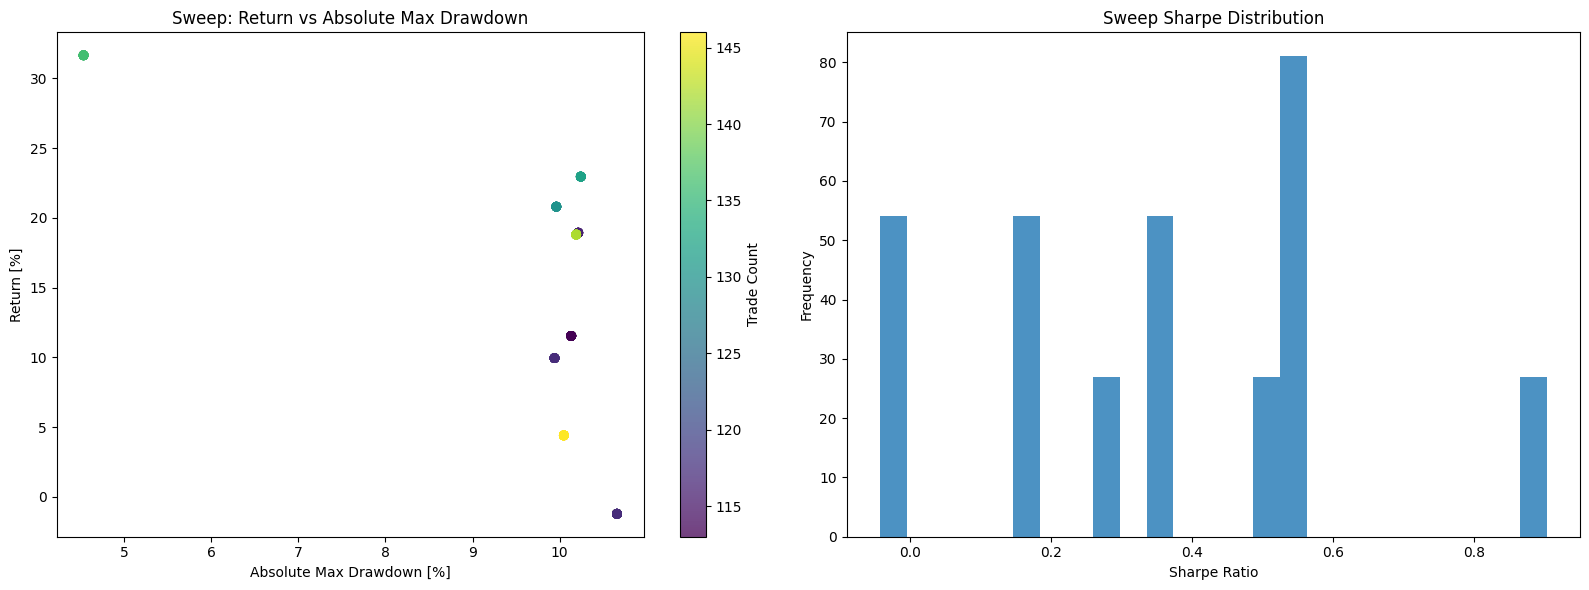

,combo_index,buy_pullback_rsi,sell_overbought_rsi,min_atr,extreme_setup_rsi,extreme_setup_rel_vol,return_pct,max_drawdown_pct,max_drawdown_abs,win_rate_pct,profit_factor,sharpe_ratio,trade_count
65,66,42.0,85.0,3.5,25.0,1.1,31.656383,-4.534939,4.534939,46.323529,1.448941,0.903432,136
34,35,42.0,82.0,3.5,35.0,1.0,31.656383,-4.534939,4.534939,46.323529,1.448941,0.903432,136
63,64,42.0,85.0,3.5,25.0,0.9,31.656383,-4.534939,4.534939,46.323529,1.448941,0.903432,136
28,29,42.0,82.0,3.5,25.0,1.0,31.656383,-4.534939,4.534939,46.323529,1.448941,0.903432,136
29,30,42.0,82.0,3.5,25.0,1.1,31.656383,-4.534939,4.534939,46.323529,1.448941,0.903432,136
30,31,42.0,82.0,3.5,30.0,0.9,31.656383,-4.534939,4.534939,46.323529,1.448941,0.903432,136
31,32,42.0,82.0,3.5,30.0,1.0,31.656383,-4.534939,4.534939,46.323529,1.448941,0.903432,136
32,33,42.0,82.0,3.5,30.0,1.1,31.656383,-4.534939,4.534939,46.323529,1.448941,0.903432,136
33,34,42.0,82.0,3.5,35.0,0.9,31.656383,-4.534939,4.534939,46.323529,1.448941,0.903432,136
35,36,42.0,82.0,3.5,35.0,1.1,31.656383,-4.534939,4.534939,46.323529,1.448941,0.903432,136


In [4]:
sweep_results_files = sorted(OUT_DIR.glob('sweep_results_msft_*.csv'))
if not sweep_results_files:
    raise ValueError('No sweep results found.')

latest_sweep_path = sweep_results_files[-1]
sweep_df = pd.read_csv(latest_sweep_path)
sweep_df['max_drawdown_abs'] = sweep_df['max_drawdown_pct'].abs()

print(f'Latest sweep file: {latest_sweep_path.name}')
print(f'Sweep rows: {len(sweep_df)}')
display(sweep_df.describe(include='all').T)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter = axes[0].scatter(
    sweep_df['max_drawdown_abs'],
    sweep_df['return_pct'],
    c=sweep_df['trade_count'],
    cmap='viridis',
    alpha=0.75
)
axes[0].set_title('Sweep: Return vs Absolute Max Drawdown')
axes[0].set_xlabel('Absolute Max Drawdown [%]')
axes[0].set_ylabel('Return [%]')
fig.colorbar(scatter, ax=axes[0], label='Trade Count')

axes[1].hist(sweep_df['sharpe_ratio'].dropna(), bins=25, alpha=0.8)
axes[1].set_title('Sweep Sharpe Distribution')
axes[1].set_xlabel('Sharpe Ratio')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

sweep_df.sort_values('return_pct', ascending=False).head(10)

In [5]:

# sweep_df.describe().T.to_excel(OUT_DIR / 'sweep_df_describe.xlsx', sheet_name='describe', index=True)
# print(f"Saved: {OUT_DIR / 'sweep_df_describe.xlsx'}")

,scenario,max_drawdown_pct,avg_drawdown_duration_bars,max_drawdown_duration_bars,drawdown_events
0,baseline,-10.242933,25.151515,320,66
1,stress_slippage_20bps,-11.605252,32.000000,471,53


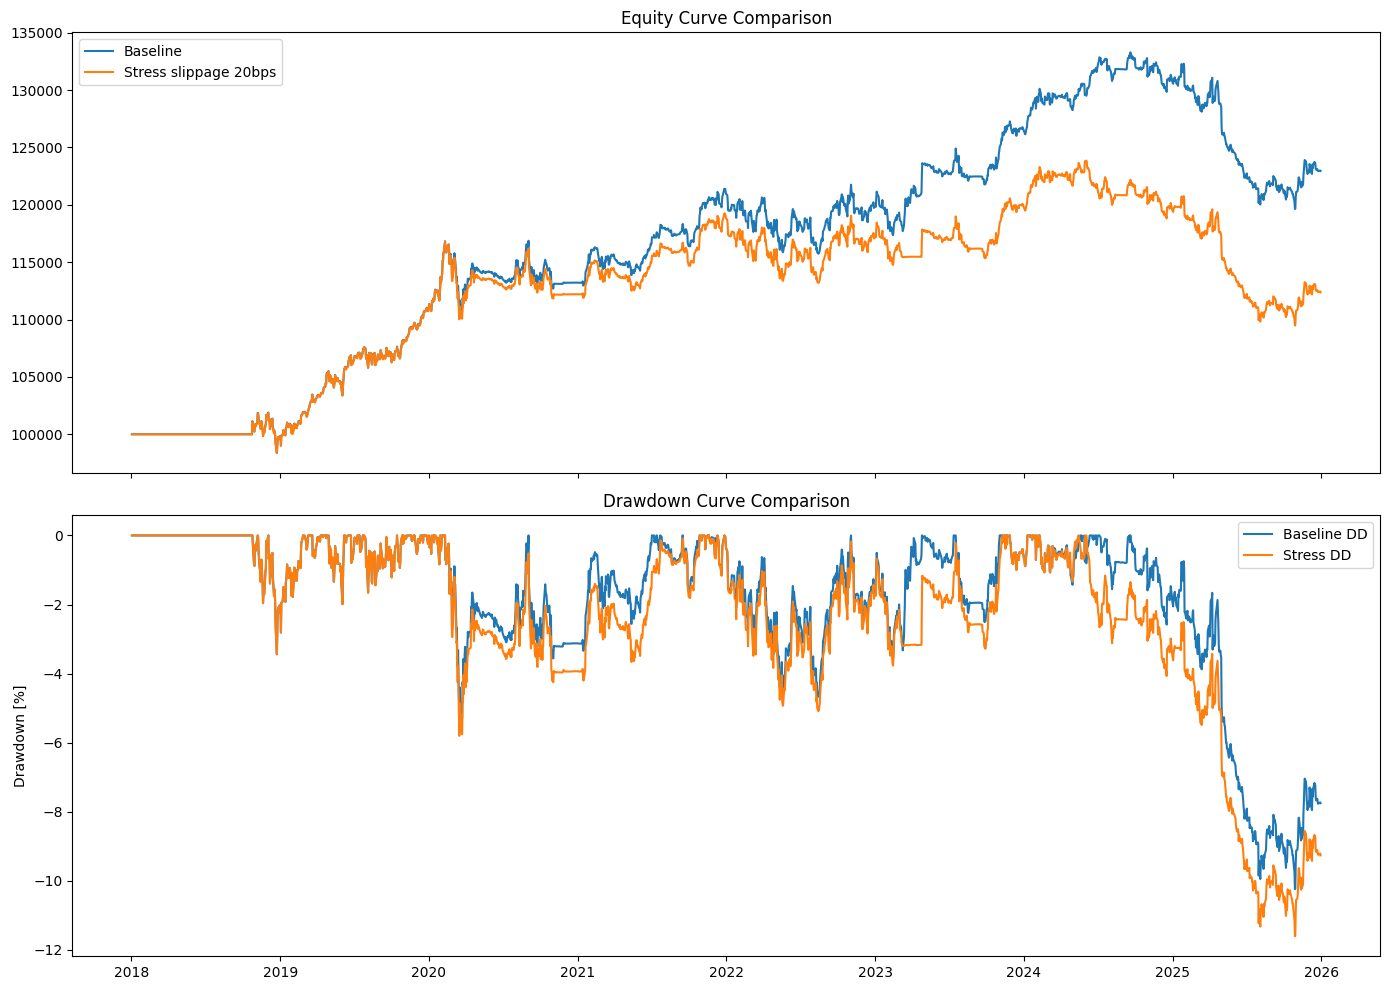

In [6]:
def load_equity_curve(run_id: str) -> pd.DataFrame:
    path = OUT_DIR / f'equity_msft_{run_id}.csv'
    if not path.exists():
        raise FileNotFoundError(path)
    eq = pd.read_csv(path)
    time_col = 'Unnamed: 0' if 'Unnamed: 0' in eq.columns else eq.columns[0]
    eq.rename(columns={time_col: 'Date'}, inplace=True)
    eq['Date'] = pd.to_datetime(eq['Date'])
    eq.set_index('Date', inplace=True)

    equity_col = 'Equity' if 'Equity' in eq.columns else None
    if equity_col is None:
        candidates = [c for c in eq.columns if 'equity' in str(c).lower()]
        if not candidates:
            raise ValueError(f'No equity column found in {path.name}')
        equity_col = candidates[0]

    return eq[[equity_col]].rename(columns={equity_col: 'Equity'})

def drawdown_stats(equity_series: pd.Series) -> dict:
    dd = equity_series / equity_series.cummax() - 1.0
    underwater = dd < 0

    durations = []
    current = 0
    for flag in underwater:
        if flag:
            current += 1
        elif current > 0:
            durations.append(current)
            current = 0
    if current > 0:
        durations.append(current)

    return {
        'max_drawdown_pct': float(dd.min() * 100),
        'avg_drawdown_duration_bars': float(np.mean(durations)) if durations else 0.0,
        'max_drawdown_duration_bars': int(max(durations)) if durations else 0,
        'drawdown_events': int(len(durations)),
    }

baseline_row = metrics_df[metrics_df['scenario'] == 'baseline'].sort_values('run_id').iloc[-1]
stress_row = metrics_df[metrics_df['scenario'] == 'stress_slippage_20bps'].sort_values('run_id').iloc[-1]

baseline_eq = load_equity_curve(str(baseline_row['run_id']))
stress_eq = load_equity_curve(str(stress_row['run_id']))

baseline_stats = drawdown_stats(baseline_eq['Equity'])
stress_stats = drawdown_stats(stress_eq['Equity'])

dd_compare = pd.DataFrame([
    {'scenario': 'baseline', **baseline_stats},
    {'scenario': 'stress_slippage_20bps', **stress_stats},
])
display(dd_compare)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
axes[0].plot(baseline_eq.index, baseline_eq['Equity'], label='Baseline')
axes[0].plot(stress_eq.index, stress_eq['Equity'], label='Stress slippage 20bps')
axes[0].set_title('Equity Curve Comparison')
axes[0].legend()

baseline_dd = baseline_eq['Equity'] / baseline_eq['Equity'].cummax() - 1.0
stress_dd = stress_eq['Equity'] / stress_eq['Equity'].cummax() - 1.0
axes[1].plot(baseline_dd.index, baseline_dd * 100, label='Baseline DD')
axes[1].plot(stress_dd.index, stress_dd * 100, label='Stress DD')
axes[1].set_title('Drawdown Curve Comparison')
axes[1].set_ylabel('Drawdown [%]')
axes[1].legend()

plt.tight_layout()
plt.show()

In [7]:
def load_trades(run_id: str) -> pd.DataFrame:
    path = OUT_DIR / f'trades_msft_{run_id}.csv'
    if not path.exists():
        return pd.DataFrame()
    t = pd.read_csv(path)
    return t

def expectancy_from_trades(trades: pd.DataFrame) -> float:
    if trades.empty or 'PnL' not in trades.columns:
        return np.nan
    wins = trades[trades['PnL'] > 0]['PnL']
    losses = trades[trades['PnL'] < 0]['PnL']

    if len(trades) == 0:
        return np.nan

    p = len(wins) / len(trades)
    avg_win = wins.mean() if len(wins) else 0.0
    avg_loss = abs(losses.mean()) if len(losses) else 0.0
    return p * avg_win - (1 - p) * avg_loss

coherence_scenarios = [
    'baseline',
    'ablation_no_streak_cap',
    'ablation_min_atr_0',
    'ablation_disable_overbought_sell',
    'ablation_disable_take_profit',
]

rows = []
for scen in coherence_scenarios:
    subset = metrics_df[metrics_df['scenario'] == scen].sort_values('run_id')
    if subset.empty:
        continue
    r = subset.iloc[-1]
    trades = load_trades(str(r['run_id']))

    rows.append({
        'scenario': scen,
        'run_id': r['run_id'],
        'return_pct': r['return_pct'],
        'max_drawdown_pct': r['max_drawdown_pct'],
        'trade_count': r['trade_count'],
        'win_rate_pct': r['win_rate_pct'],
        'sharpe_ratio': r['sharpe_ratio'],
        'profit_factor': r['profit_factor'],
        'expectancy_per_trade': expectancy_from_trades(trades),
    })

ablation_df = pd.DataFrame(rows)
if not ablation_df.empty and 'baseline' in ablation_df['scenario'].values:
    base = ablation_df[ablation_df['scenario'] == 'baseline'].iloc[0]
    for col in ['return_pct', 'max_drawdown_pct', 'trade_count', 'win_rate_pct', 'sharpe_ratio', 'profit_factor', 'expectancy_per_trade']:
        ablation_df[f'delta_{col}'] = ablation_df[col] - base[col]

ablation_df.sort_values('scenario')

,scenario,run_id,return_pct,max_drawdown_pct,trade_count,win_rate_pct,sharpe_ratio,profit_factor,expectancy_per_trade,delta_return_pct,delta_max_drawdown_pct,delta_trade_count,delta_win_rate_pct,delta_sharpe_ratio,delta_profit_factor,delta_expectancy_per_trade
3,ablation_disable_overbought_sell,20260319_133704,22.955589,-10.242933,132,45.454545,0.540759,1.443008,173.905976,2.842171e-14,0.000000,0,0.000000,0.000000,-2.220446e-16,1.421085e-13
4,ablation_disable_take_profit,20260319_133707,74.917164,-17.101339,1,100.000000,0.664726,NaN,74917.164349,5.196158e+01,-6.858405,-131,54.545455,0.123967,NaN,7.474326e+04
2,ablation_min_atr_0,20260319_133700,4.408198,-10.048359,146,45.205479,0.146682,1.264232,30.193137,-1.854739e+01,0.194574,14,-0.249066,-0.394077,-1.787764e-01,-1.437128e+02
1,ablation_no_streak_cap,20260319_133656,22.955589,-10.242933,132,45.454545,0.540759,1.443008,173.905976,2.842171e-14,0.000000,0,0.000000,0.000000,-2.220446e-16,1.421085e-13
0,baseline,20260319_131152,22.955589,-10.242933,132,45.454545,0.540759,1.443008,173.905976,0.000000e+00,0.000000,0,0.000000,0.000000,0.000000e+00,0.000000e+00


,window,return_pct,max_drawdown_pct,win_rate_pct,sharpe_ratio,profit_factor,trade_count
13,2020-01-01 to 2021-12-31,7.855082,-2.086019,46.666667,1.227070,2.373676,30
12,2021-01-01 to 2022-12-31,-2.215598,-2.880880,36.842105,-0.939125,0.585878,19
14,2022-01-01 to 2023-12-31,2.760578,-2.912359,48.387097,0.584864,1.927872,31
15,2023-01-01 to 2024-12-31,1.162496,-3.305811,30.434783,0.217717,0.908648,23
16,2024-01-01 to 2025-12-31,-6.293266,-9.475711,0.000000,-0.943875,0.000000,2


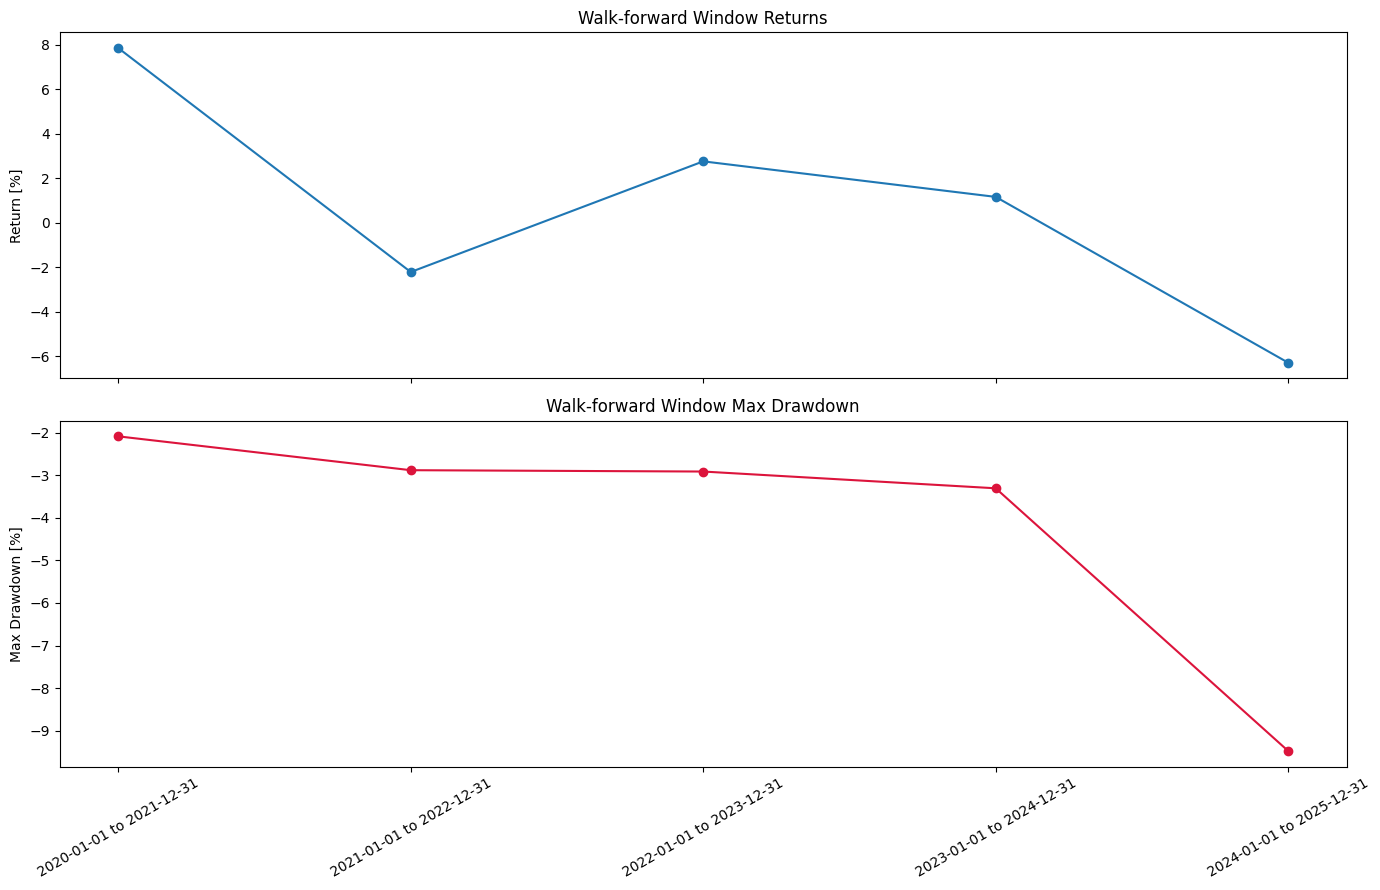

In [8]:
wf_mask = metrics_df['scenario'].str.startswith('walk_forward_') | (metrics_df['scenario'] == 'edge_2022_and_walkforward')
walk_df = metrics_df[wf_mask].copy().sort_values(['start_cfg', 'end_cfg', 'run_id'])

walk_df = walk_df.drop_duplicates(subset=['start_cfg', 'end_cfg'], keep='last')
walk_df['window'] = walk_df['start_cfg'] + ' to ' + walk_df['end_cfg']

walk_cols = ['window', 'return_pct', 'max_drawdown_pct', 'win_rate_pct', 'sharpe_ratio', 'profit_factor', 'trade_count']
display(walk_df[walk_cols])

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
axes[0].plot(walk_df['window'], walk_df['return_pct'], marker='o')
axes[0].set_title('Walk-forward Window Returns')
axes[0].set_ylabel('Return [%]')
axes[0].tick_params(axis='x', rotation=30)

axes[1].plot(walk_df['window'], walk_df['max_drawdown_pct'], marker='o', color='crimson')
axes[1].set_title('Walk-forward Window Max Drawdown')
axes[1].set_ylabel('Max Drawdown [%]')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## Reviewer Notes Template

Use this section to summarize findings for external review:

1. Overfitting risk:
- Distribution shape across sweep (return, drawdown, Sharpe)
- Position of selected baseline in parameter population

2. Drawdown realism:
- Baseline vs stress drawdown depth and duration
- Recovery characteristics and frequency of drawdown events

3. Entry/exit coherence:
- Which ablations materially change expectancy and profit factor
- Whether coherence holds in 2022-focused and walk-forward windows